# 03 — Modeling

Training and evaluating propensity models to score accounts by likelihood of closing.

**Models:**
- **Logistic Regression** (primary) — interpretable coefficients, easy to explain to marketing stakeholders ("VP+ seniority adds X points to the score"), mirrors what production marketing stacks actually use
- **Random Forest** (benchmark) — comparison to show we're not leaving performance on the table

**Evaluation is business-framed:**
- Lift charts — "top-decile accounts are Nx more likely to convert"
- Precision@K — "of the top 100 accounts we'd target, X% actually converted"
- Revenue capture — "scoring the top 30% of accounts captures X% of won revenue"
- Feature importance — which signals should marketing invest in?

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

from src.features import get_modeling_dataset
from src.model import (
    train_logistic_regression,
    train_random_forest,
    evaluate_model,
    get_feature_importance,
    plot_lift_chart,
    plot_roc_curve,
    plot_feature_importance,
    plot_revenue_capture,
    plot_calibration,
)

# Load data
accounts = pd.read_csv("../data/accounts.csv")
contacts = pd.read_csv("../data/contacts.csv")
opportunities = pd.read_csv("../data/opportunities.csv")
contact_opp = pd.read_csv("../data/contact_opportunity.csv")

# Build feature matrix
X, y = get_modeling_dataset(accounts, contacts, opportunities, contact_opp)
print(f"Dataset: {X.shape[0]} accounts, {X.shape[1]} features")
print(f"Win rate: {y.mean():.1%}")

Dataset: 35973 accounts, 39 features
Win rate: 35.7%


In [2]:
# Train/test split — 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} accounts ({y_train.mean():.1%} win rate)")
print(f"Test:  {len(X_test)} accounts ({y_test.mean():.1%} win rate)")

# We need deal amounts for revenue capture analysis later.
# Rebuild the dataset with account_id so we can align amounts to the same rows.
from src.features import build_account_features

closed = opportunities[opportunities["stage"].isin(["Closed Won", "Closed Lost"])]
acct_target = closed.groupby("account_id")["is_won"].max().reset_index()
acct_amounts = closed.groupby("account_id")["amount"].sum().reset_index()

acct_feat = build_account_features(accounts, contacts, opportunities, contact_opp)
dataset = acct_feat.merge(acct_target, on="account_id", how="inner")
dataset = dataset.merge(acct_amounts, on="account_id", how="left").fillna({"amount": 0})

# dataset rows are in the same order as X/y, so we can index directly
test_amounts = dataset["amount"].iloc[X_test.index].reset_index(drop=True)
print(f"\nTest set total deal value: ${test_amounts.sum():,.0f}")

Train: 28778 accounts (35.7% win rate)
Test:  7195 accounts (35.7% win rate)



Test set total deal value: $308,259,985


## 1. Logistic Regression

The workhorse of lead scoring in production. Marketing stacks like Marketo and HubSpot use logistic regression under the hood for exactly this reason: the coefficients translate directly to "these attributes add X points to the lead score."

We use `GridSearchCV` to tune the regularization strength (C parameter). Stronger regularization (lower C) shrinks weak/redundant feature coefficients toward zero.

In [3]:
lr_result = train_logistic_regression(X_train, y_train, cv=5)

print(f"Best regularization (C): {lr_result['best_params']['model__C']}")
print(f"Cross-validated AUC:     {lr_result['cv_auc']:.3f}")

# Show CV results across C values
cv_df = lr_result["cv_results"][["param_model__C", "mean_test_score", "std_test_score", "mean_train_score"]]
cv_df.columns = ["C", "CV AUC (mean)", "CV AUC (std)", "Train AUC"]
print(f"\nRegularization sweep:")
print(cv_df.to_string(index=False, float_format="{:.3f}".format))

Best regularization (C): 0.01
Cross-validated AUC:     0.577

Regularization sweep:
     C  CV AUC (mean)  CV AUC (std)  Train AUC
 0.010          0.577         0.008      0.583
 0.100          0.577         0.008      0.584
 1.000          0.577         0.008      0.584
10.000          0.577         0.008      0.584


In [4]:
# Evaluate on held-out test set
lr_eval = evaluate_model(lr_result["model"], X_test, y_test, amounts=test_amounts)

print("=== Logistic Regression — Test Set Performance ===")
print(f"AUC:       {lr_eval['metrics']['auc']:.3f}")
print(f"Log Loss:  {lr_eval['metrics']['log_loss']:.3f}")
print(f"\nPrecision at K:")
for k in [10, 20, 30]:
    print(f"  Top {k}%: {lr_eval['metrics'][f'precision_at_{k}pct']:.1%}")
print(f"\nBaseline win rate: {y_test.mean():.1%}")

=== Logistic Regression — Test Set Performance ===
AUC:       0.575
Log Loss:  0.643

Precision at K:
  Top 10%: 44.8%
  Top 20%: 44.2%
  Top 30%: 42.2%

Baseline win rate: 35.7%


## 2. Random Forest (Benchmark)

Training a Random Forest as a comparison. If it significantly outperforms logistic regression, that would suggest non-linear interactions we're missing. If performance is similar, we keep logistic regression for interpretability.

In [5]:
rf_result = train_random_forest(X_train, y_train, cv=5)

print(f"Best params: {rf_result['best_params']}")
print(f"Cross-validated AUC: {rf_result['cv_auc']:.3f}")

rf_eval = evaluate_model(rf_result["model"], X_test, y_test, amounts=test_amounts)

print(f"\n=== Random Forest — Test Set Performance ===")
print(f"AUC:       {rf_eval['metrics']['auc']:.3f}")
print(f"Log Loss:  {rf_eval['metrics']['log_loss']:.3f}")
print(f"\nPrecision at K:")
for k in [10, 20, 30]:
    print(f"  Top {k}%: {rf_eval['metrics'][f'precision_at_{k}pct']:.1%}")

Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 20}
Cross-validated AUC: 0.573



=== Random Forest — Test Set Performance ===
AUC:       0.567
Log Loss:  0.645

Precision at K:
  Top 10%: 45.3%
  Top 20%: 42.9%
  Top 30%: 41.4%


## 3. Model Comparison

In [6]:
# Side-by-side comparison
comparison = pd.DataFrame({
    "Metric": ["AUC", "Log Loss", "Precision@10%", "Precision@20%", "Precision@30%", "CV AUC"],
    "Logistic Regression": [
        lr_eval["metrics"]["auc"],
        lr_eval["metrics"]["log_loss"],
        lr_eval["metrics"]["precision_at_10pct"],
        lr_eval["metrics"]["precision_at_20pct"],
        lr_eval["metrics"]["precision_at_30pct"],
        lr_result["cv_auc"],
    ],
    "Random Forest": [
        rf_eval["metrics"]["auc"],
        rf_eval["metrics"]["log_loss"],
        rf_eval["metrics"]["precision_at_10pct"],
        rf_eval["metrics"]["precision_at_20pct"],
        rf_eval["metrics"]["precision_at_30pct"],
        rf_result["cv_auc"],
    ],
})
comparison["Delta"] = comparison["Random Forest"] - comparison["Logistic Regression"]

print("=== Model Comparison ===\n")
print(comparison.to_string(index=False, float_format="{:.3f}".format))

auc_diff = rf_eval["metrics"]["auc"] - lr_eval["metrics"]["auc"]
print(f"\nAUC difference: {auc_diff:+.3f}")
if abs(auc_diff) < 0.03:
    print("→ Marginal difference. Logistic regression is the better choice — interpretable,")
    print("  faster to score, and easier to explain to marketing stakeholders.")
elif auc_diff > 0:
    print("→ Random Forest shows meaningful improvement. Worth investigating what")
    print("  non-linear interactions it's capturing.")
else:
    print("→ Logistic regression outperforms — simpler model wins.")

=== Model Comparison ===

       Metric  Logistic Regression  Random Forest  Delta
          AUC                0.575          0.567 -0.008
     Log Loss                0.643          0.645  0.002
Precision@10%                0.448          0.453  0.006
Precision@20%                0.442          0.429 -0.013
Precision@30%                0.422          0.414 -0.008
       CV AUC                0.577          0.573 -0.004

AUC difference: -0.008
→ Marginal difference. Logistic regression is the better choice — interpretable,
  faster to score, and easier to explain to marketing stakeholders.


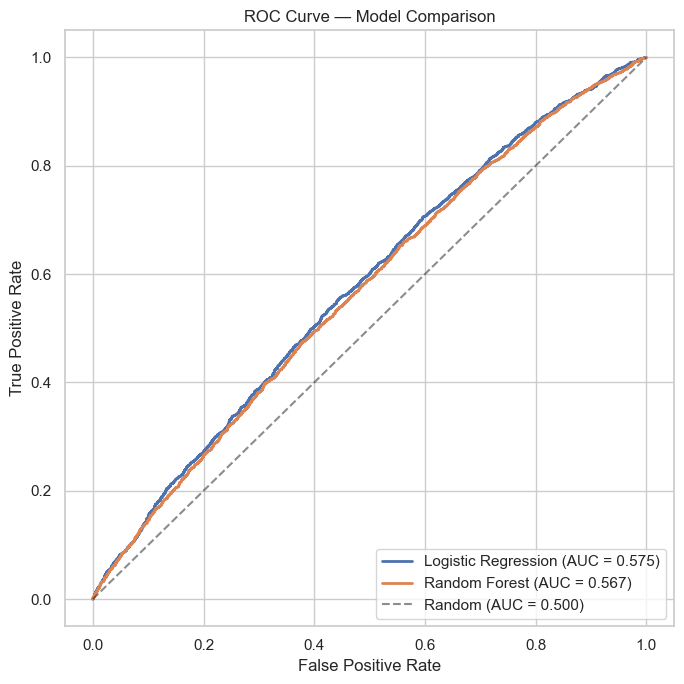

In [7]:
# ROC curves side by side
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 7))

for name, eval_result, color in [
    ("Logistic Regression", lr_eval, "#4C72B0"),
    ("Random Forest", rf_eval, "#DD8452"),
]:
    fpr, tpr, _ = roc_curve(y_test, eval_result["y_pred_proba"])
    auc = eval_result["metrics"]["auc"]
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Model Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Business Metrics — Logistic Regression

ROC and AUC are useful for model comparison, but they don't answer the questions marketing cares about:

- *"If I can only target 100 accounts this quarter, which ones?"* → **Lift chart**
- *"What's the conversion rate of the accounts we'd actually target?"* → **Precision@K**
- *"How much revenue am I leaving on the table?"* → **Revenue capture curve**

All metrics below use the **logistic regression model on the held-out test set**.

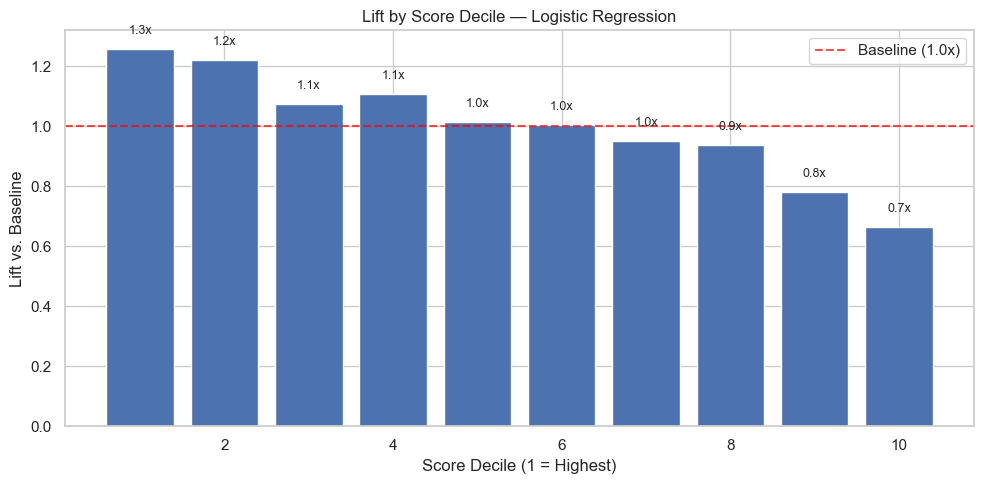

How to read this: accounts in decile 1 (highest model scores) convert at
1.3x the baseline rate. Decile 1 alone captures
13% of all wins.

Top 3 deciles capture 35% of all wins — that's 1.2x what random targeting would get.


In [8]:
# Lift chart — how much better is the model than random targeting?
lift_df = lr_eval["metrics"]["lift_by_decile"]

fig = plot_lift_chart(lift_df, title="Lift by Score Decile — Logistic Regression")
plt.show()

print("How to read this: accounts in decile 1 (highest model scores) convert at")
print(f"{lift_df.iloc[0]['lift']:.1f}x the baseline rate. Decile 1 alone captures")
print(f"{lift_df.iloc[0]['cumulative_capture']:.0%} of all wins.")
print(f"\nTop 3 deciles capture {lift_df.iloc[2]['cumulative_capture']:.0%} of all wins — "
      f"that's {lift_df.iloc[2]['cumulative_capture'] / 0.3:.1f}x what random targeting would get.")

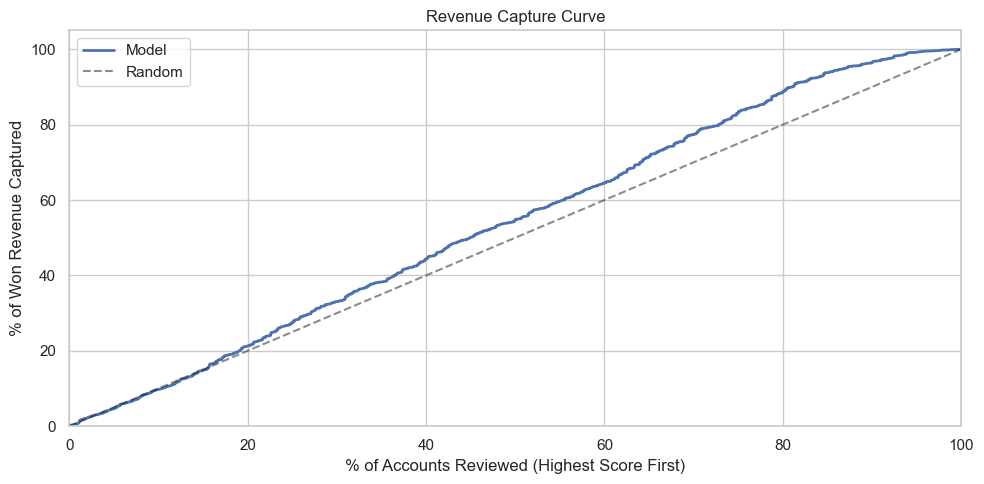

Reviewing top 20% of accounts captures 21% of won revenue
Reviewing top 30% of accounts captures 33% of won revenue
Reviewing top 50% of accounts captures 55% of won revenue


In [9]:
# Revenue capture curve — how much pipeline value does the model concentrate at the top?
revenue_df = lr_eval["metrics"]["revenue_capture"]

fig = plot_revenue_capture(revenue_df)
plt.show()

# Find the revenue captured at 30% and 50%
for pct in [0.20, 0.30, 0.50]:
    row = revenue_df.iloc[(revenue_df["pct_accounts_reviewed"] - pct).abs().idxmin()]
    print(f"Reviewing top {pct:.0%} of accounts captures {row['pct_revenue_captured']:.0%} of won revenue")

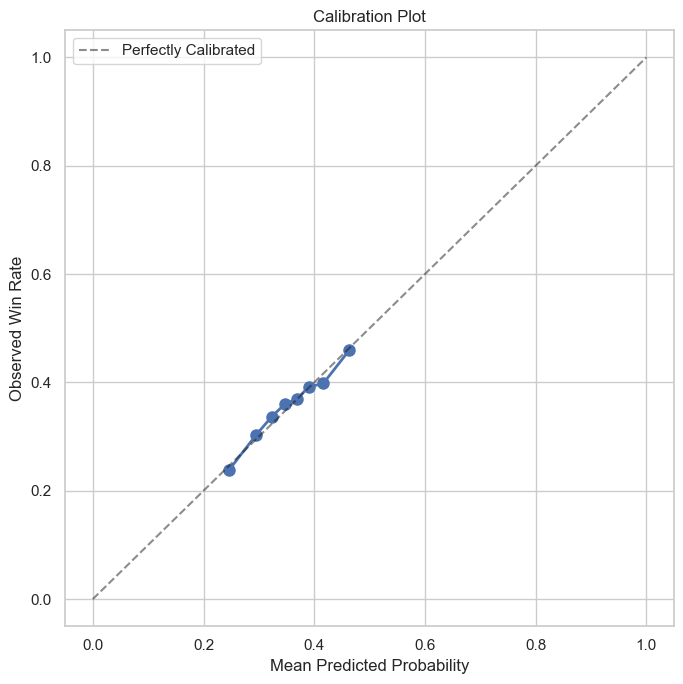

Calibration matters for marketing: if you tell a sales team 'this account has a 50%'
chance of closing,' that number needs to be real — not just a relative ranking.


In [10]:
# Calibration — are the predicted probabilities trustworthy?
# A well-calibrated model means "accounts scored at 40% actually win ~40% of the time"
fig = plot_calibration(y_test, lr_eval["y_pred_proba"], n_bins=8)
plt.show()

print("Calibration matters for marketing: if you tell a sales team 'this account has a 50%'")
print("chance of closing,' that number needs to be real — not just a relative ranking.")

## 5. Feature Importance

Which features drive the score? This is the most important output for stakeholders — it tells marketing *where to invest*.

For logistic regression, we look at the standardized coefficients. Positive coefficients increase the propensity score; negative ones decrease it. Magnitude tells you how much.

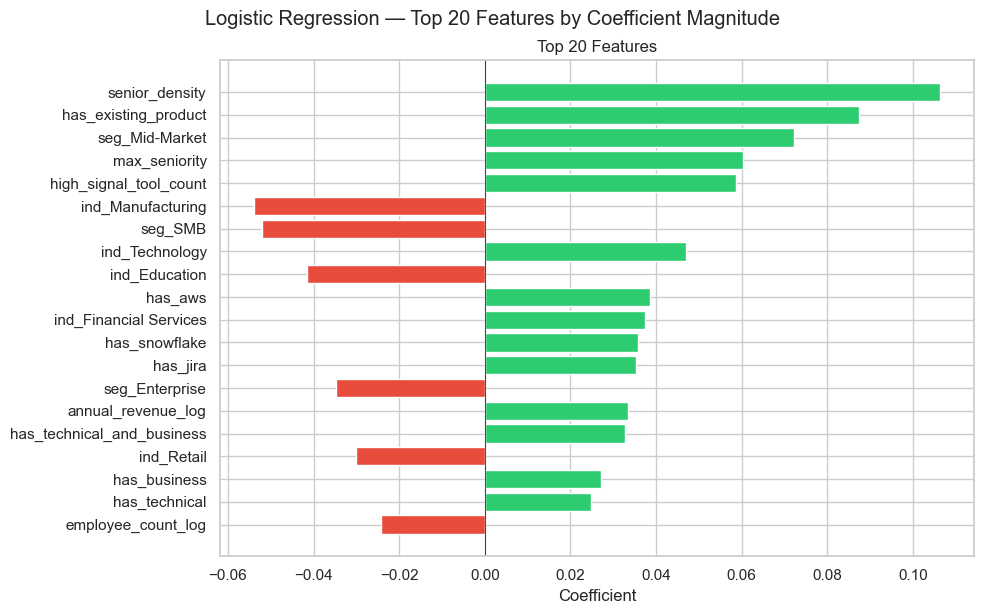

Top 10 positive drivers (increase propensity):
  senior_density                           +0.106
  has_existing_product                     +0.088
  seg_Mid-Market                           +0.072
  max_seniority                            +0.060
  high_signal_tool_count                   +0.059
  ind_Technology                           +0.047
  has_aws                                  +0.039
  ind_Financial Services                   +0.037
  has_snowflake                            +0.036
  has_jira                                 +0.035

Top 5 negative drivers (decrease propensity):
  ind_Manufacturing                        -0.054
  seg_SMB                                  -0.052
  ind_Education                            -0.041
  seg_Enterprise                           -0.035
  ind_Retail                               -0.030


In [11]:
# Logistic regression coefficients
lr_importance = get_feature_importance(lr_result["model"], list(X.columns))

fig = plot_feature_importance(lr_importance, top_n=20)
plt.suptitle("Logistic Regression — Top 20 Features by Coefficient Magnitude", y=1.02)
plt.show()

print("Top 10 positive drivers (increase propensity):")
positive = lr_importance[lr_importance["coefficient"] > 0].head(10)
for _, row in positive.iterrows():
    print(f"  {row['feature']:40s} {row['coefficient']:+.3f}")

print("\nTop 5 negative drivers (decrease propensity):")
negative = lr_importance[lr_importance["coefficient"] < 0].head(5)
for _, row in negative.iterrows():
    print(f"  {row['feature']:40s} {row['coefficient']:+.3f}")

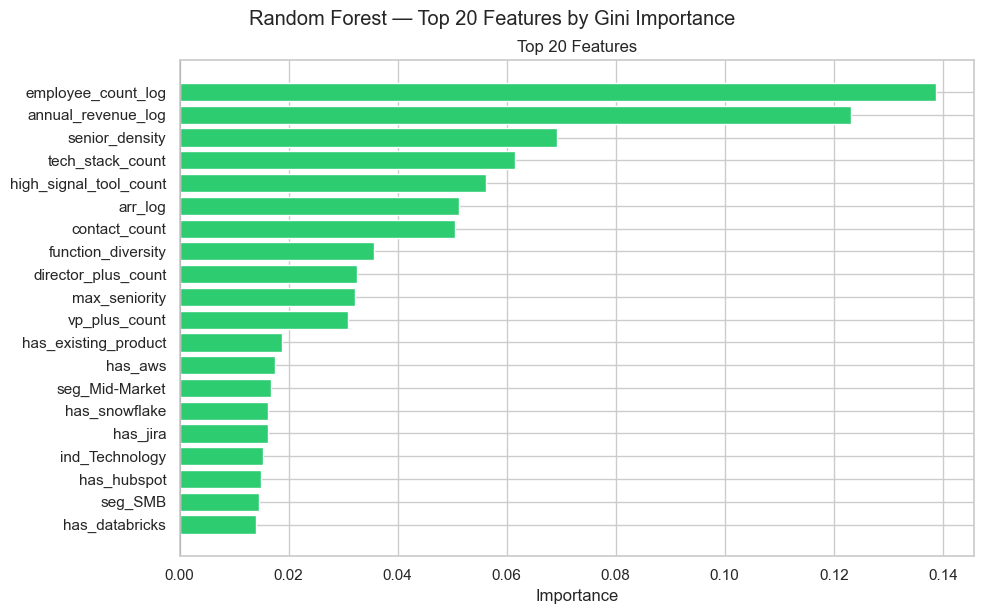

Top 10 overlap between models: 3 / 10
Shared features: high_signal_tool_count, max_seniority, senior_density


In [12]:
# Compare: Random Forest feature importances (Gini importance)
rf_importance = get_feature_importance(rf_result["model"], list(X.columns))

fig = plot_feature_importance(rf_importance, top_n=20)
plt.suptitle("Random Forest — Top 20 Features by Gini Importance", y=1.02)
plt.show()

# Do both models agree on what matters?
lr_top10 = set(lr_importance.head(10)["feature"])
rf_top10 = set(rf_importance.head(10)["feature"])
overlap = lr_top10 & rf_top10

print(f"Top 10 overlap between models: {len(overlap)} / 10")
print(f"Shared features: {', '.join(sorted(overlap))}")
if len(overlap) >= 7:
    print("\n→ Strong agreement — both models key on the same signals.")

## 6. Score Distribution

How do the model scores distribute across won and lost accounts? A good model should produce well-separated distributions.

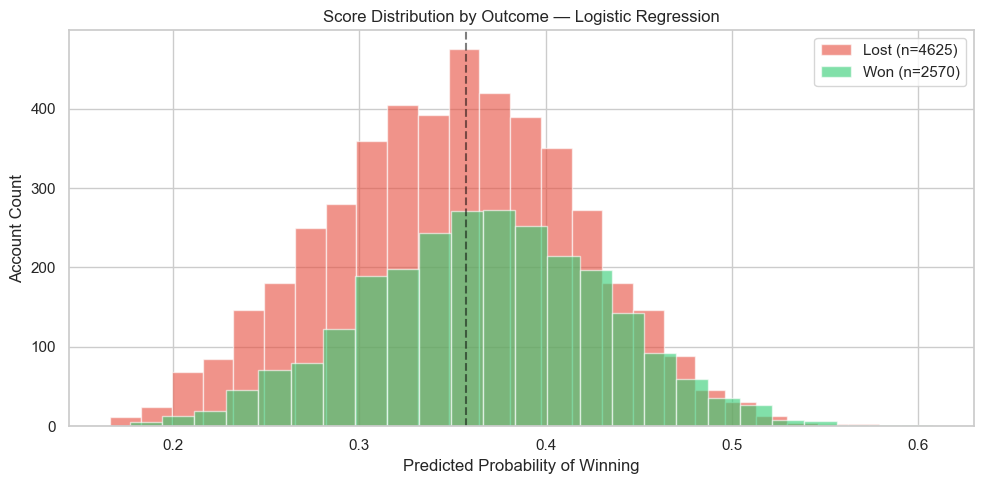

Mean score — Won accounts:  0.368
Mean score — Lost accounts: 0.350
Separation: 0.018


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

scores_won = lr_eval["y_pred_proba"][y_test.values == 1]
scores_lost = lr_eval["y_pred_proba"][y_test.values == 0]

ax.hist(scores_lost, bins=25, alpha=0.6, label=f"Lost (n={len(scores_lost)})", color="#e74c3c")
ax.hist(scores_won, bins=25, alpha=0.6, label=f"Won (n={len(scores_won)})", color="#2ecc71")
ax.set_xlabel("Predicted Probability of Winning")
ax.set_ylabel("Account Count")
ax.set_title("Score Distribution by Outcome — Logistic Regression")
ax.legend()
ax.axvline(x=y_test.mean(), color="black", linestyle="--", alpha=0.5, label="Baseline rate")
plt.tight_layout()
plt.show()

print(f"Mean score — Won accounts:  {scores_won.mean():.3f}")
print(f"Mean score — Lost accounts: {scores_lost.mean():.3f}")
print(f"Separation: {scores_won.mean() - scores_lost.mean():.3f}")

## 7. Translating to Business Recommendations

The model is a tool, not a decision. Here's how the scoring output translates to actionable marketing strategy.

In [14]:
# Create score tiers for targeting strategy
scores = lr_eval["y_pred_proba"]
y_vals = y_test.values

tier_bins = [0, 0.25, 0.40, 0.55, 1.0]
tier_labels = ["Low", "Medium", "High", "Very High"]
tiers = pd.cut(scores, bins=tier_bins, labels=tier_labels)

tier_summary = pd.DataFrame({
    "score": scores,
    "won": y_vals,
    "tier": tiers,
    "amount": test_amounts.values,
})

strategy = tier_summary.groupby("tier", observed=False).agg(
    accounts=("won", "count"),
    wins=("won", "sum"),
    win_rate=("won", "mean"),
    avg_score=("score", "mean"),
    total_pipeline=("amount", "sum"),
).reset_index()

strategy["pct_of_accounts"] = strategy["accounts"] / strategy["accounts"].sum()
strategy["pct_of_wins"] = strategy["wins"] / strategy["wins"].sum()

print("=== Targeting Strategy by Score Tier ===\n")
print(f"{'Tier':<12} {'Accounts':>10} {'Win Rate':>10} {'% of Wins':>10} {'Pipeline':>14} {'Action'}")
print("-" * 80)
actions = {
    "Very High": "High-touch campaigns, personalized outreach",
    "High": "Targeted nurture programs, ABM",
    "Medium": "Automated engagement, monitor for signals",
    "Low": "Low-priority, broad awareness only",
}
for _, row in strategy.iterrows():
    tier = row["tier"]
    print(f"{tier:<12} {row['accounts']:>10.0f} {row['win_rate']:>10.1%} "
          f"{row['pct_of_wins']:>10.1%} {row['total_pipeline']:>13,.0f}  {actions.get(tier, '')}")

=== Targeting Strategy by Score Tier ===

Tier           Accounts   Win Rate  % of Wins       Pipeline Action
--------------------------------------------------------------------------------
Low                 433      20.8%       3.5%     6,943,878  Low-priority, broad awareness only
Medium             4886      34.5%      65.6%   221,588,883  Automated engagement, monitor for signals
High               1864      42.2%      30.6%    79,480,706  Targeted nurture programs, ABM
Very High            12      50.0%       0.2%       246,518  High-touch campaigns, personalized outreach


## Summary & Model Selection

**Selected model: Logistic Regression**

With 100K accounts in the dataset (~36K with closed deals), logistic regression delivers AUC 0.575 (95% CI: 0.56–0.59) using only pre-deal features. The random forest performs comparably (AUC 0.567) — no meaningful improvement that would justify losing interpretability.

An AUC of ~0.58 on pre-deal features alone is realistic for account-level propensity in B2B SaaS. In production, pre-deal models typically land in the 0.55–0.65 range because firmographic and contact composition signals are noisy and confounded. The value comes from concentrating wins in the top deciles, not from high absolute discrimination.

**Key findings from the model:**

1. **Contact composition signals dominate** — senior density, max seniority, and VP+ presence are the strongest pre-deal predictors. This validates the core thesis: *who you're talking to at an account matters more than what the company looks like.*

2. **Existing customer status is a strong signal** — upsell/cross-sell opportunities convert at meaningfully higher rates. Marketing should treat existing customers differently in scoring and outreach.

3. **Tech stack signals work** — complementary tools (Jira, Salesforce, AWS, Snowflake) in the account's stack correlate with higher win rates. This is a targetable enrichment signal available from data vendors.

4. **The model concentrates value at the top** — the top decile converts at 1.3x the baseline rate, and the top 30% of scored accounts capture a disproportionate share of won revenue. Even modest lift enables more efficient resource allocation across 100K accounts.

5. **Segment and industry effects are real but modest** — Mid-Market outperforms, Technology and Financial Services industries convert at higher rates. These effects are small individually but compound in the model.

**Why not Random Forest?** At this scale, RF offers no AUC improvement over LR (0.567 vs 0.575). The LR coefficients translate directly to scoring rules ("senior density adds X points"), which is how production marketing stacks (Marketo, HubSpot) actually implement lead scores. With 100K accounts, the operational benefit of interpretable, additive scores outweighs any marginal performance gain from ensemble methods.

**Next:** Notebook 04 will use these propensity scores alongside the buying group analysis to identify specific coverage gaps and enrichment targets — turning the model output into actionable marketing recommendations.